# SHAP Analysis — Binary XGBoost Ensemble

This notebook computes SHAP values for all XGBoost models in the binary
best-architecture ensemble, visualises the aggregated feature importances,
and analyses variance across the 25 models.

**Base-score fix** — XGBoost >= 2.0 serialises `base_score` differently than
what older SHAP versions expect.  We patch each Booster to 0.5 via its JSON
config before creating a `TreeExplainer`.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import logging
from pathlib import Path
from typing import Any, Dict, List, Tuple, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import xgboost as xgb
from datasets import load_dataset
from dotenv import load_dotenv

load_dotenv()

import sys
sys.path.insert(0, str(Path('..').resolve()))

from tackai.ensemble_predictor import EnsemblePredictor

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

## Configuration

In [3]:
ENSEMBLE_DIR = Path('../ensembles/ensembles/bin_best_arch_ensemble')
PLOT_DIR = Path('../plots/shap')
TOP_K = 10

DC50_THRESHOLD = 100.0  # nM
DMAX_THRESHOLD = 80.0   # %

FONT_FAMILY = 'sans-serif'
TITLE_FONTSIZE = 14
LABEL_FONTSIZE = 12
TICK_FONTSIZE = 10
DPI = 300
FIG_WIDTH_PT = 506.295 * 1.5

COLORS = {
    'blue':   '#4B9ECE',
    'orange': '#FFAA6E',
    'green':  '#9DCE9C',
    'purple': '#C8ABDA',
}

plt.rcParams.update({
    'font.family':        FONT_FAMILY,
    'font.size':          TICK_FONTSIZE,
    'axes.titlesize':     TITLE_FONTSIZE,
    'axes.labelsize':     LABEL_FONTSIZE,
    'xtick.labelsize':    TICK_FONTSIZE,
    'ytick.labelsize':    TICK_FONTSIZE,
    'savefig.dpi':        DPI,
    'savefig.bbox':       'tight',
})

## Binary label helper

In [4]:
def get_bin_label(
    row: Union[pd.Series, Dict[str, Any]],
    dmax_threshold: float = 80.0,
    dc50_threshold: float = 100.0,
) -> Union[int, float]:
    """Return 1 (active), 0 (inactive), or np.nan (unknown)."""
    dc50 = row.get('DC50', np.nan)
    dmax = row.get('Dmax', np.nan)

    if pd.notna(dc50) and float(dc50) >= dc50_threshold:
        return 0
    if pd.notna(dmax) and float(dmax) < dmax_threshold:
        return 0
    if pd.isna(dc50) or pd.isna(dmax):
        return np.nan
    if float(dc50) < dc50_threshold and float(dmax) >= dmax_threshold:
        return 1
    return 0


def _assign_activity(row: pd.Series) -> Union[int, float]:
    return get_bin_label({
        'DC50': row.get('Value_DC50', np.nan),
        'Dmax': row.get('Value_Dmax', np.nan),
    })

## Load held-out set

In [5]:
logger.info('Loading TACK multitask dataset...')
ds = load_dataset('ailab-bio/TACK', 'multitask', split='train')
df = ds.to_pandas()

held_out_df = df[df['SMILES_Held_Out']].copy().reset_index(drop=True)
held_out_df['Activity'] = held_out_df.apply(_assign_activity, axis=1)
held_out_df = (
    held_out_df[held_out_df['Activity'].notna()]
    .copy()
    .reset_index(drop=True)
)
held_out_df['Activity'] = held_out_df['Activity'].astype(int)

n_active = int((held_out_df['Activity'] == 1).sum())
n_inactive = int((held_out_df['Activity'] == 0).sum())
print(f'Held-out: {len(held_out_df)} samples  ({n_active} active / {n_inactive} inactive)')
held_out_df.head()

Held-out: 196 samples  (108 active / 88 inactive)


,SMILES,POI_Name,POI_Sequence,Ligase_Name,Cell_Line,Value_Type_DC50,Value_Unit_DC50,Value_DC50,Value_Error_DC50,Value_Range_Min_DC50,...,Value_Dmax,Value_Error_Dmax,Value_Range_Min_Dmax,Value_Range_Max_Dmax,Value_Concentration_Dmax,Value_Operator_Dmax,Value_Category_Dmax,Value_Concentration_Unit_Dmax,TPD_ID_Dmax,Activity
0,C#Cc1cccc2cc(O)cc(-c3ncc4c(N5CC6CCC(C5)N6)nc(O...,KRAS,MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVI...,CRBN,SW1990,DC50,nM,1000.0,NaN,NaN,...,30.0,NaN,10.0,50.0,NaN,NaN,range,NaN,TPD-8K0O8T,0
1,CC(C)(O)c1c(NC(=O)c2cccc(C3CC3(F)F)n2)cn2cc(C3...,IRAK4,MNKPITPSTYVRCLNVGLIRKLSDFIDPQEGWKKLAVAIKKPSGDD...,CRBN,HEK293,DC50,nM,5.0,NaN,NaN,...,96.0,NaN,NaN,NaN,NaN,NaN,numeric,NaN,TPD-ERMM4B,1
2,CC(F)(F)C1=C(C#N)C=CC(N2CCC(c3ccc(N4CCC(CN5CCN...,AR,MEVQLGLGRVYPRPPSKTYRGAFQNLFQSVREVIQNPGPRHPEAAS...,CRBN,LNCaP,DC50,nM,48.3,NaN,NaN,...,86.0,NaN,NaN,NaN,NaN,NaN,numeric,NaN,TPD-NLX336,1
3,CC1(C)C(=O)N(c2ccc(C#N)c(Cl)c2)c2ccc(C3=CC=C(N...,AR,MEVQLGLGRVYPRPPSKTYRGAFQNLFQSVREVIQNPGPRHPEAAS...,CRBN,VCaP,DC50,nM,121.0,NaN,NaN,...,56.0,NaN,NaN,NaN,NaN,NaN,numeric,NaN,TPD-Z4E72Q,0
4,CC1(C)CN(c2ccc(C#N)c(C(F)(F)F)c2)CC[C@H]1c1ccc...,AR,MEVQLGLGRVYPRPPSKTYRGAFQNLFQSVREVIQNPGPRHPEAAS...,CRBN,LNCaP,DC50,nM,20.4,NaN,NaN,...,92.0,NaN,NaN,NaN,NaN,NaN,numeric,NaN,TPD-N6802I,1


## Load ensemble

In [12]:
predictor = EnsemblePredictor.from_directory(ENSEMBLE_DIR)

xgb_names = [
    name for name, mtype in predictor.model_types.items()
    if mtype == 'xgboost'
]
print(f'{len(xgb_names)} XGBoost models loaded.')

Found 25 model files in ../ensembles/ensembles/bin_best_arch_ensemble


  Loaded (1/25): model=xgboost_bin_protac-data=fp512r16_all_desc_poi_emb_lig_emb_cell_text_assay_time_poi_pca44_lig_pca7_labels_Activity-group=scaffold-fold=15 (xgboost)


  Loaded (2/25): model=xgboost_bin_protac-data=fp512r16_all_desc_poi_emb_lig_emb_cell_text_assay_time_poi_pca44_lig_pca7_labels_Activity-group=scaffold-fold=20 (xgboost)


  Loaded (3/25): model=xgboost_bin_protac-data=fp512r16_all_desc_poi_emb_lig_emb_cell_text_assay_time_poi_pca44_lig_pca7_labels_Activity-group=scaffold-fold=9 (xgboost)


  Loaded (4/25): model=xgboost_bin_protac-data=fp512r16_all_desc_poi_emb_lig_emb_cell_text_assay_time_poi_pca44_lig_pca7_labels_Activity-group=scaffold-fold=22 (xgboost)


...

  Loaded (21/25): model=xgboost_bin_protac-data=fp512r16_all_desc_poi_emb_lig_emb_cell_text_assay_time_poi_pca44_lig_pca7_labels_Activity-group=scaffold-fold=24 (xgboost)


  Loaded (22/25): model=xgboost_bin_protac-data=fp512r16_all_desc_poi_emb_lig_emb_cell_text_assay_time_poi_pca44_lig_pca7_labels_Activity-group=scaffold-fold=2 (xgboost)


  Loaded (23/25): model=xgboost_bin_protac-data=fp512r16_all_desc_poi_emb_lig_emb_cell_text_assay_time_poi_pca44_lig_pca7_labels_Activity-group=scaffold-fold=18 (xgboost)


  Loaded (24/25): model=xgboost_bin_protac-data=fp512r16_all_desc_poi_emb_lig_emb_cell_text_assay_time_poi_pca44_lig_pca7_labels_Activity-group=scaffold-fold=19 (xgboost)


  Loaded (25/25): model=xgboost_bin_protac-data=fp512r16_all_desc_poi_emb_lig_emb_cell_text_assay_time_poi_pca44_lig_pca7_labels_Activity-group=scaffold-fold=16 (xgboost)
25 XGBoost models loaded.


## Featurization helper

In [7]:
def build_feature_matrix(
    datamodule: Any,
    records: List[Dict[str, Any]],
) -> Tuple[np.ndarray, List[str]]:
    """Return (X, feature_names) for *records* using *datamodule*."""
    batch = datamodule.featurize_samples_batch(records, return_tensor='xgb')
    X = np.vstack([item[0] for item in batch]).astype(np.float32)
    feature_names = list(batch[0][1])
    return X, feature_names

## Base-score fix

In [ ]:
import builtins
import shap.explainers._tree as _shap_tree
from contextlib import contextmanager

@contextmanager
def _shap_xgb2_compat():
    """Patch shap.TreeExplainer to handle XGBoost >=2.0 bracketed base_score.

    XGBoost >=2.0 stores scalar model params as '[5E-1]'; SHAP's
    XGBTreeModelLoader calls float() on them directly and raises ValueError.
    We temporarily shadow float() in SHAP's module namespace with a version
    that strips the brackets before converting.
    See: https://github.com/shap/shap/issues/4184
    """
    def _robust_float(x):
        if isinstance(x, str):
            x = x.strip('[]')
        return builtins.float(x)

    _shap_tree.float = _robust_float
    try:
        yield
    finally:
        _shap_tree.__dict__.pop('float', None)

## Compute SHAP values

In [18]:
records = held_out_df.to_dict('records')

shap_values_list: List[np.ndarray] = []
expected_values_list: List[float] = []
feature_names: List[str] = []

for idx, model_name in enumerate(xgb_names):
    model = predictor.models[model_name]
    dm = predictor.datamodules[model_name]

    X, fnames = build_feature_matrix(dm, records)

    if not feature_names:
        feature_names = fnames
    
    with _shap_xgb2_compat():
        explainer = shap.TreeExplainer(model)

    shap_vals = explainer.shap_values(X)

    # Older SHAP may return [neg_class, pos_class] for binary:logistic
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]

    ev = explainer.expected_value
    if isinstance(ev, (list, np.ndarray)):
        ev = float(np.asarray(ev).flat[0])
    expected_values_list.append(ev)

    shap_values_list.append(shap_vals)
    print(f'  [{idx+1:2d}/{len(xgb_names)}] shape={shap_vals.shape}')

shap_array = np.array(shap_values_list, dtype=np.float32)  # (n_models, n_samples, n_features)
expected_values = np.array(expected_values_list, dtype=np.float32)

print(f'\nSHAP array shape: {shap_array.shape}  (models × samples × features)')
print(f'Expected values — mean: {expected_values.mean():.4f}  std: {expected_values.std():.4f}')

  [ 1/25] shape=(196, 1562)
  [ 2/25] shape=(196, 1562)
  [ 3/25] shape=(196, 1562)
  [ 4/25] shape=(196, 1562)
  [ 5/25] shape=(196, 1562)
  [ 6/25] shape=(196, 1562)
  [ 7/25] shape=(196, 1562)
  [ 8/25] shape=(196, 1562)
  [ 9/25] shape=(196, 1562)
  [10/25] shape=(196, 1562)
  [11/25] shape=(196, 1562)
  [12/25] shape=(196, 1562)
  [13/25] shape=(196, 1562)
  [14/25] shape=(196, 1562)
  [15/25] shape=(196, 1562)
  [16/25] shape=(196, 1562)
  [17/25] shape=(196, 1562)
  [18/25] shape=(196, 1562)
  [19/25] shape=(196, 1562)
  [20/25] shape=(196, 1562)
  [21/25] shape=(196, 1562)
  [22/25] shape=(196, 1562)
  [23/25] shape=(196, 1562)
  [24/25] shape=(196, 1562)
  [25/25] shape=(196, 1562)

SHAP array shape: (25, 196, 1562)  (models × samples × features)
Expected values — mean: -0.0041  std: 0.0020


## Build feature DataFrame (first model's normalisation)

In [19]:
first_dm = predictor.datamodules[xgb_names[0]]
X_first, _ = build_feature_matrix(first_dm, records)
X_held_out = pd.DataFrame(X_first, columns=feature_names)
print(f'Feature matrix: {X_held_out.shape}')
X_held_out.head()

Feature matrix: (196, 1562)


,Feature_Assay_0,Feature_Assay_1,Feature_Assay_2,Feature_Assay_3,Feature_Assay_4,Feature_Assay_5,Feature_Assay_6,Feature_Assay_7,Feature_Assay_8,Feature_Assay_9,...,Feature_POI_Precomputed_Embedding_34,Feature_POI_Precomputed_Embedding_35,Feature_POI_Precomputed_Embedding_36,Feature_POI_Precomputed_Embedding_37,Feature_POI_Precomputed_Embedding_38,Feature_POI_Precomputed_Embedding_39,Feature_POI_Precomputed_Embedding_40,Feature_POI_Precomputed_Embedding_41,Feature_POI_Precomputed_Embedding_42,Feature_POI_Precomputed_Embedding_43
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.077962,0.019378,-0.001310,0.045343,0.031074,0.005069,-0.010915,-0.001985,-0.007536,0.001232
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.089611,-0.021950,0.082085,0.020574,-0.084024,-0.126452,0.048966,0.037317,0.136923,-0.011180
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.020694,-0.043265,0.049719,0.015416,0.026661,-0.010301,0.042176,-0.018416,0.032247,-0.036838
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.020694,-0.043265,0.049719,0.015416,0.026661,-0.010301,0.042176,-0.018416,0.032247,-0.036838
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.020694,-0.043265,0.049719,0.015416,0.026661,-0.010301,0.042176,-0.018416,0.032247,-0.036838


## Aggregate SHAP values

In [20]:
mean_shap = np.mean(shap_array, axis=0)           # (n_samples, n_features)
abs_per_model = np.mean(np.abs(shap_array), axis=1)  # (n_models, n_features)
ens_mean_abs = np.mean(abs_per_model, axis=0)     # (n_features,)
ens_std_abs  = np.std(abs_per_model,  axis=0)     # (n_features,)

# Top-k features by mean |SHAP|
top_idx_asc  = np.argsort(ens_mean_abs)[-TOP_K:]   # ascending; lowest first
top_idx_desc = top_idx_asc[::-1]                    # descending; highest first

def _strip(name: str) -> str:
    return name.replace('Feature_', '')

top_labels_asc  = [_strip(X_held_out.columns[i]) for i in top_idx_asc]
top_labels_desc = [_strip(X_held_out.columns[i]) for i in top_idx_desc]
top_means = ens_mean_abs[top_idx_asc]
top_stds  = ens_std_abs[top_idx_asc]

print('Top features (descending importance):')
for label, mean, std in zip(top_labels_desc, top_means[::-1], top_stds[::-1]):
    print(f'  {label:50s}  {mean:.4f} ± {std:.4f}')

Top features (descending importance):
  Descriptor_fr_Ar_NH                                 0.1306 ± 0.0997
  Cell_Line_ID_Description_13                         0.0905 ± 0.0635
  Descriptor_MaxAbsPartialCharge                      0.0846 ± 0.0419
  POI_Precomputed_Embedding_4                         0.0739 ± 0.0344
  Cell_Line_ID_Description_412                        0.0633 ± 0.0446
  Descriptor_EState_VSA4                              0.0603 ± 0.0204
  Descriptor_BCUT2D_MWLOW                             0.0546 ± 0.0280
  POI_Precomputed_Embedding_38                        0.0521 ± 0.0896
  Descriptor_fr_Nhpyrrole                             0.0485 ± 0.0373
  Cell_Line_ID_Description_496                        0.0421 ± 0.0419


## Panel A — Beeswarm summary plot

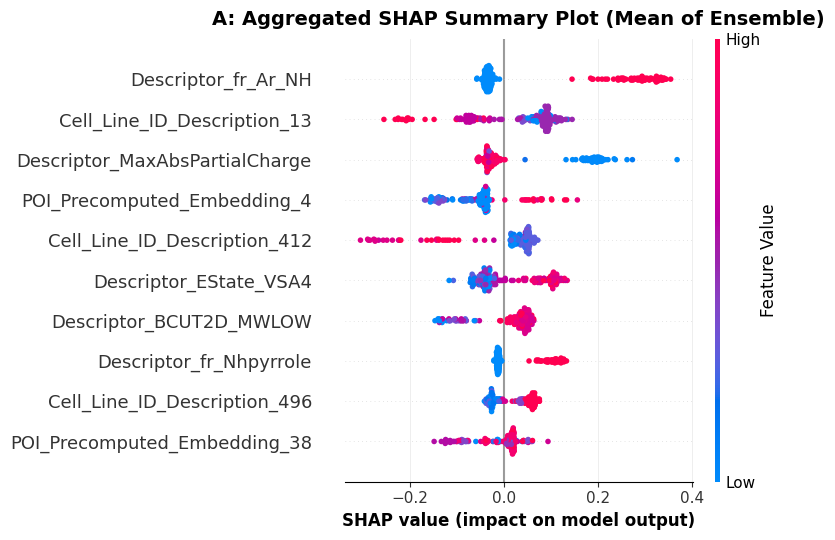

In [21]:
fig_a, ax_a = plt.subplots(1, 1, figsize=(FIG_WIDTH_PT / 72.27, 5.0))
plt.sca(ax_a)
shap.summary_plot(
    mean_shap[:, top_idx_desc],
    features=X_held_out.iloc[:, top_idx_desc],
    feature_names=top_labels_desc,
    max_display=TOP_K,
    show=False,
    plot_type='dot',
    color_bar_label='Feature Value',
)
ax_a.set_title(
    'A: Aggregated SHAP Summary Plot (Mean of Ensemble)',
    fontsize=TITLE_FONTSIZE, fontweight='bold', pad=10,
)
ax_a.set_xlabel(
    'SHAP value (impact on model output)',
    fontsize=LABEL_FONTSIZE, fontweight='bold',
)
ax_a.grid(axis='x', alpha=0.3, linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

List of RDKit features in the top 10 by mean absolute SHAP value:

- `fr_Ar_NH`: Number of aromatic amines
- `MaxAbsPartialCharge`: Returns molecular charge descriptors
- `EState_VSA4`: EState VSA Descriptor 4 ( 0.72 <= x < 1.17) (more information at this [reference](https://greglandrum.github.io/rdkit-blog/posts/2023-04-17-what-are-the-vsa-descriptors.html))
- `BCUT2D_MWLOW`: Represents the lowest eigenvalue of the Burden matrix, which is weighted specifically by atomic mass
- `fr_Nhpyrrole`: Number of H-pyrrole nitrogens

## Panel B — Importance stability (±1 std-dev)

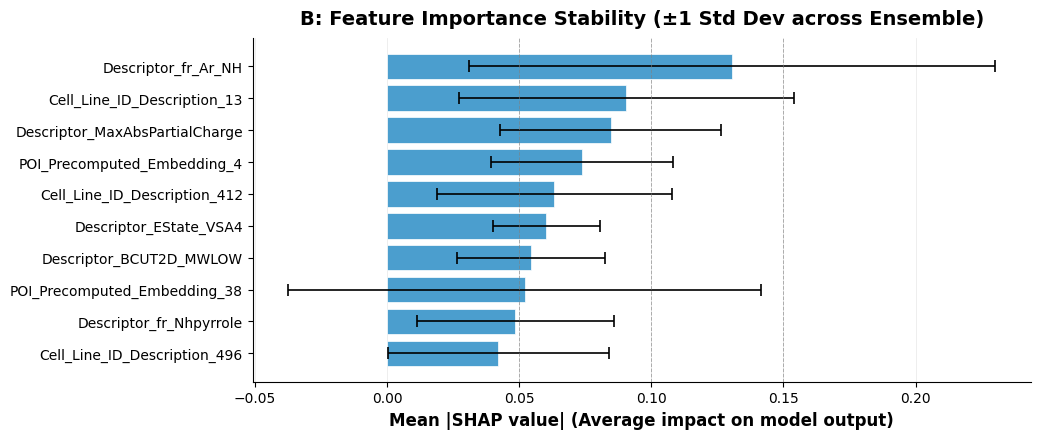

In [22]:
fig_b, ax_b = plt.subplots(1, 1, figsize=(FIG_WIDTH_PT / 72.27, 4.5))

y_pos = np.arange(TOP_K)
ax_b.barh(
    y_pos,
    top_means,
    xerr=top_stds,
    capsize=4,
    color=COLORS['blue'],
    edgecolor='white',
    linewidth=0.5,
    error_kw=dict(lw=1.2, capthick=1.2, ecolor='black'),
)
ax_b.set_yticks(y_pos)
ax_b.set_yticklabels(top_labels_asc, fontsize=TICK_FONTSIZE)
ax_b.set_xlabel(
    'Mean |SHAP value| (Average impact on model output)',
    fontsize=LABEL_FONTSIZE, fontweight='bold',
)
ax_b.set_title(
    'B: Feature Importance Stability (±1 Std Dev across Ensemble)',
    fontsize=TITLE_FONTSIZE, fontweight='bold', pad=10,
)
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)
ax_b.grid(axis='x', alpha=0.3, linestyle='-', linewidth=0.5)
ax_b.set_axisbelow(True)

x_max = (top_means + top_stds).max()
for xval in [0.05, 0.10, 0.15]:
    if xval <= x_max * 1.1:
        ax_b.axvline(x=xval, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)

plt.tight_layout()
plt.show()

## Combined figure (A + B)

Saved shap_ensemble_bin.pdf
Saved shap_ensemble_bin.png
Saved shap_ensemble_bin.svg


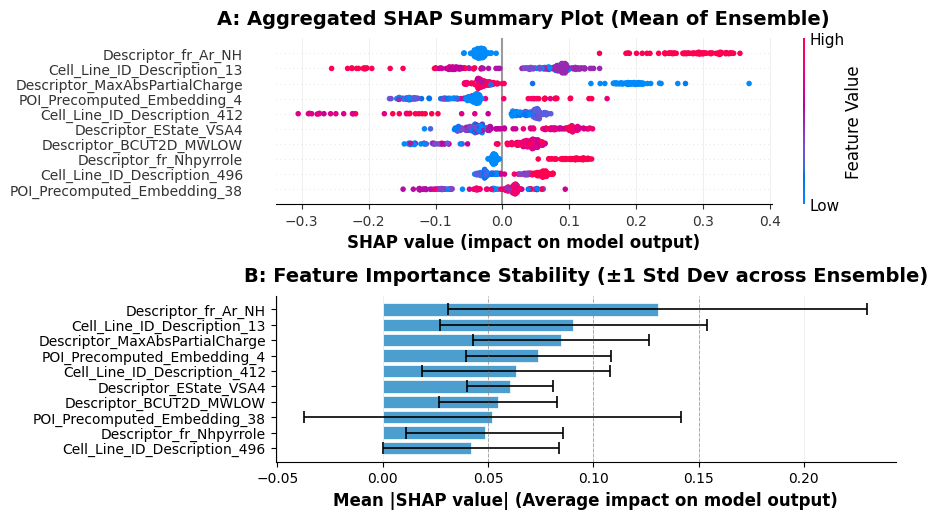

In [23]:
PLOT_DIR.mkdir(parents=True, exist_ok=True)

fig_w = FIG_WIDTH_PT / 72.27
fig_h = fig_w * 0.65

fig = plt.figure(figsize=(fig_w, fig_h))
gs = fig.add_gridspec(2, 1, hspace=0.55)

ax_beeswarm = fig.add_subplot(gs[0])
ax_bar = fig.add_subplot(gs[1])

# ---- Panel A ----
plt.sca(ax_beeswarm)
shap.summary_plot(
    mean_shap[:, top_idx_desc],
    features=X_held_out.iloc[:, top_idx_desc],
    feature_names=top_labels_desc,
    max_display=TOP_K,
    show=False,
    plot_type='dot',
    color_bar_label='Feature Value',
)
ax_beeswarm.set_title(
    'A: Aggregated SHAP Summary Plot (Mean of Ensemble)',
    fontsize=TITLE_FONTSIZE, fontweight='bold', pad=10,
)
ax_beeswarm.set_xlabel(
    'SHAP value (impact on model output)',
    fontsize=LABEL_FONTSIZE, fontweight='bold',
)
ax_beeswarm.grid(axis='x', alpha=0.3, linestyle='-', linewidth=0.5)
ax_beeswarm.tick_params(labelsize=TICK_FONTSIZE)

# ---- Panel B ----
y_pos = np.arange(TOP_K)
ax_bar.barh(
    y_pos,
    top_means,
    xerr=top_stds,
    capsize=4,
    color=COLORS['blue'],
    edgecolor='white',
    linewidth=0.5,
    error_kw=dict(lw=1.2, capthick=1.2, ecolor='black'),
)
ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels(top_labels_asc, fontsize=TICK_FONTSIZE)
ax_bar.set_xlabel(
    'Mean |SHAP value| (Average impact on model output)',
    fontsize=LABEL_FONTSIZE, fontweight='bold',
)
ax_bar.set_title(
    'B: Feature Importance Stability (±1 Std Dev across Ensemble)',
    fontsize=TITLE_FONTSIZE, fontweight='bold', pad=10,
)
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)
ax_bar.grid(axis='x', alpha=0.3, linestyle='-', linewidth=0.5)
ax_bar.set_axisbelow(True)

x_max = (top_means + top_stds).max()
for xval in [0.05, 0.10, 0.15]:
    if xval <= x_max * 1.1:
        ax_bar.axvline(x=xval, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)

for ext in ('pdf', 'png', 'svg'):
    fig.savefig(PLOT_DIR / f'shap_ensemble_bin.{ext}', format=ext)
    print(f'Saved shap_ensemble_bin.{ext}')

plt.show()

## Expected value diagnostics

If the 25 models forming the ensemble were trained on subsets with drastically different data distributions (e.g., highly imbalanced strata), the base values $v_k (\emptyset)$ for each model $k$ could differ significantly, which would make the averaged SHAP matrix less meaningful. In such cases, the interpretation of the averaged SHAP values might be compromised, as they would not be anchored to a consistent baseline across models. To check for this, we can print out the `explainer.expected_value` for all 25 models. If the variance across these baselines is small, it indicates that the models are anchored to similar baselines, and thus the averaged SHAP matrix is valid and ready for inclusion in the appendix.

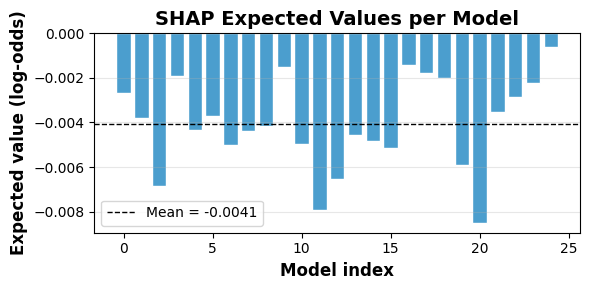

Expected value  mean=-0.0041  std=0.0020


In [24]:
fig_ev, ax_ev = plt.subplots(figsize=(6, 3))
ax_ev.bar(range(len(expected_values)), expected_values, color=COLORS['blue'], edgecolor='white')
ax_ev.axhline(expected_values.mean(), color='black', linestyle='--', lw=1, label=f'Mean = {expected_values.mean():.4f}')
ax_ev.set_xlabel('Model index', fontweight='bold')
ax_ev.set_ylabel('Expected value (log-odds)', fontweight='bold')
ax_ev.set_title('SHAP Expected Values per Model', fontweight='bold')
ax_ev.legend()
ax_ev.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Expected value  mean={expected_values.mean():.4f}  std={expected_values.std():.4f}')